![](../../../images/header.png)

# Mapping the Universe

<h6>Author : Hernan Rincon</h6>
<h6>Last Updated : October 11, 2025</h6>

The DESI Survey is making a giant, three-dimensional map of the universe. This map will allow scientists to study some of the biggest mysteries in physics, chief among them being the nature of dark energy. Most maps that you see in your day-to-day life are two-dimensional, so it may be hard to picture what a three dimensional map looks like in your head. This notebook will detail how DESI is creating its map of the universe, what this map looks like, and how you can create your own version of such a map with DESI data.

By the end of this notebook, you should be able to:
- Read maps of the night sky with right ascension and declination coordinates
- Understand the concept of a survey footprint and how DESI observes the night sky with overlapping survey tiles
- Create a three-dimensional map of DESI galaxies along with a corresponding two-dimensional cross section

## Preferred Backgrounds
While not necessary, having knowledge about the following topics will be helpful in completing this notebook on time:

- How Jupyter cells work
- How to depict data visually by using graphs

**Run the cell below to load the basic Python packages we need to run this notebook.**

In [ ]:
import numpy as np
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from desihigh.plot_utilities import angle_degrees_formatter

## 1 - Map Projections

Before we discuss maps of the universe, let's first introduce maps of the Earth. Since our planet Earth is a sphere, we will often make maps that are **projections** of this sphere onto a flat surface, like the one seen below.

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>

Maps that are projections will often distort the shapes of Earth's continents in order to represent a three-dimensional planet on a two-dimensional surface. That is the case for the map pictured above.

Maps of the night sky can also be projected onto a two-dimensional map. The below map is one such example. This map shows the band of the Milky Way galaxy, which you can see by eye in dark night skies far away from city lights.

<img src="../../../images/Milky_Way_infrared.jpg" alt="" width="600"/>

<h6> Source : <a href="https://www.ipac.caltech.edu/2mass/">Two Micron All Sky Survey</a></h6>

As is the case for Earth's continents, objects in the night sky may appear distorted by the projection of the map. To better understand how this distortion behaves, let's make our own map of the night sky. We will use data from the <a href="https://map.gsfc.nasa.gov/">WMAP collaboration</a> that tells us how hot or cold the electromagnetic radiation in different parts of the night sky is.

First, let's load in the WMAP temperature data.

In [355]:
# load in temperature map data
sky_map = hp.read_map('../../../data/wmap_band_iqumap_r9_7yr_W_v4.fits')

Now let's create a map of the temperature of the night sky. The appearance of the map will depend on the rotation at which we view it. Run the below cell to create the map.

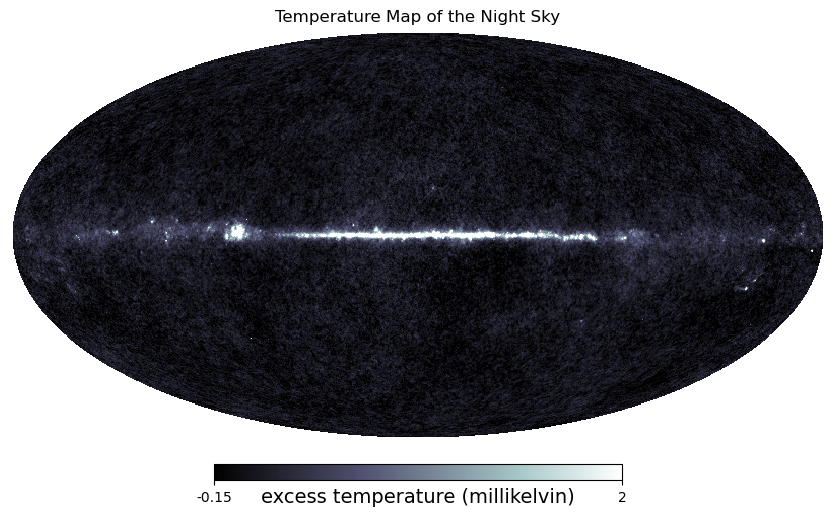

In [380]:
# Try changing the value of map_rotation_angle to various 
# values between 0 and 360 degrees and observe how the 
# apparence of the map changes

map_rotation_angle = 0 # in units of degrees

# create the map by using the mollview function
hp.mollview(
    sky_map,
    rot = (0, 0, map_rotation_angle),
    title="Temperature Map of the Night Sky",
    unit="excess temperature (millikelvin)",
    min=-.15,
    max=2,
    cmap = mpl.colormaps['bone']
)


### 1.1 - Longitude and Latitude

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>


To tell where we are located on our planet Earth, we can use **longitude (long.)** and **latitude (lat.)**. Longitude and latitude are angles and have units of degrees (°). To become more familiar with these units, let’s take a look at the below map. Our friend BaoBan the coyote (the DESI outreach ambassador) is hanging out in the center of the map.

<img src="../../../images/latlong/Earth-Mollweide-projection_0.jpg" alt="" width="600"/>

The blue line on this map is called the equator, and it passes through South America, Africa, and Asia (and BaoBan). When we are on the equator, we have a latitude of 0 degrees. When we are north of (above) the equator, we have a positive latitude value, with the largest possible latitude value being 90 degrees at the north pole. When we are south of (below) the equator, we have a negative latitude value, with the lowest possible latitude value being -90 degrees at the south pole.

The green line on the map is called the Prime Meridian, and it passes through Europe, Africa, and Antarctica (and BaoBan). When we are on the Prime Meridian, we have a longitude of 0 degrees. When we are east (right) of the Prime Meridian, we have a positive longitude with the largest possible latitude value being 180 degrees on the eastern edge of the map. When we are west (left) of the equator, we have a negative latitude value, with the lowest possible longitude value being -180 degrees at the western edge of the map.


The equator and the Prime Meridian cross each other in the center of the map. BaoBan is at this location, which is labeled 0 degrees longitude and 0 degrees latitude. Let’s now go with BaoBan on an adventure around the world. If BaoBan moves east (right) on the map, then his longitude value will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_1.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 34 degrees and a latitude of 0 degrees, and he is near Lake Victoria. This lake is one of the largest in the world and is bordered by several countries in Africa. If BaoBan next moves north (up) on the map, his latitude will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_2.jpg" alt="" width="600"/>

BaoBan now has a longitude of 34 degrees and a latitude of 40 degrees, and he is in the country of Turkey. If he next moves to the east, his longitude value will increase, and he will pass through Asia and cross the Pacific Ocean. He will then wrap around the edge of the map and arrive in North America.

<img src="../../../images/latlong/Earth-Mollweide-projection_3.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 286 degrees and a latitude of 40 degrees. He is in the United States. Now he is west (left) of the Prime Meridian, so it would be conventional to write his longitude as a negative value. However, we are going to use our own custom convention and keep his longitude as a positive number. Next, BaoBan is going to head south, so his latitude will decrease.

<img src="../../../images/latlong/Earth-Mollweide-projection_4.jpg" alt="" width="600"/>

BaoBan is now south of the equator, so he has a negative latitude of -14 degrees. He is in the country of Peru. For the last stretch of his journey, he will move east, so his longitude will increase.

<img src="../../../images/latlong/Earth-Mollweide-projection_5.jpg" alt="" width="600"/>

Now BaoBan is back at the Prime Meridian, and his longitude has increased to 360 degrees. Since there are only 360 degrees in a circle, an angle of 360 degrees is equivalent to an angle of 0 degrees. So we can also say that Baoban has a longitude of 0 degrees.

TODO: add some images of locaitons ot break up teh trvel, add a plotting excersize where ou can specify lon lat

In [2]:
import numpy as np
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
import matplotlib.patheffects as patheffects

In [4]:
earth_map = np.fromfile('../../../data/earth_map_healpix.BIN', dtype=np.float32)


can you find a lat lon value in north America? Africa? Australia? Antartica?

In [542]:
def add_lat(latitudes, rotate=None, color='gray', coord='earth'):

    if coord == 'earth':
        flip = 1
    elif coord == 'sky':
        flip = -1
    else:
        err_txt = f'invalid cood value: {coord}'
        raise ValueError(err_txt)

    for latitude in latitudes:
    
        lons = np.linspace(-180, 180, 1000)
        lats = latitude + np.zeros(1000)

        if rotate is None:
            lons_transform, lats_transform = lons, lats
        else:
            lons_transform, lats_transform = rotate(lons, lats, lonlat=True)
    
        
        if color == 'gray':
            linewidth = 3 if np.isclose(latitude%360, 0) else 1
            plot = plt.scatter(flip*np.deg2rad(lons_transform), np.deg2rad(lats_transform), color='gray', alpha=.2, s=linewidth)
        else:
            plot = plt.scatter(flip*np.deg2rad(lons_transform), np.deg2rad(lats_transform), color=color, s=2)
    return plot

def add_lon(longitudes, rotate=None, color='gray', coord='earth'):

    if coord == 'earth':
        flip = 1
    elif coord == 'sky':
        flip = -1
    else:
        err_txt = f'invalid cood value: {coord}'
        raise ValueError(err_txt)

    for longitude in longitudes:

        if coord == 'sky':
            longitude=(longitude+180)%360 - 180
            
        lons = longitude + np.zeros(1000) 
        lats = np.linspace(-90, 90, 1000) 
        
        if rotate is None:
            lons_transform, lats_transform = lons, lats
        else:
            lons_transform, lats_transform = rotate(lons, lats, lonlat=True)

        if color == 'gray':
            linewidth = 3 if np.isclose(longitude%360, 0) else 1
            plot = plt.scatter(flip*np.deg2rad(lons_transform), np.deg2rad(lats_transform) , color='gray', alpha=.2, s=linewidth)
        else:
            plot = plt.scatter(flip*np.deg2rad(lons_transform), np.deg2rad(lats_transform), color=color, s=2)
    return plot

def add_coordinate(latitude, longitude, rotate, zorder, coord='earth'):

    if coord == 'earth':
        text_longitude = f'long = {longitude}'
        text_latitude = f'lat = {latitude}'
        flip=1
    elif coord == 'sky':
        text_longitude = f'RA = {longitude}'
        text_latitude = f'dec = {latitude}'
        longitude=(longitude+180)%360 - 180
        flip=-1
    else:
        err_txt = f'invalid cood value: {coord}'
        raise ValueError(err_txt)

    if rotate is None:
        longitude_transform, latitude_transform = longitude, latitude
    else:
        longitude_transform, latitude_transform = rotate(longitude, latitude, lonlat=True)
    plt.scatter(flip*np.deg2rad([longitude_transform]), np.deg2rad([latitude_transform]), color='red', marker='*', s=500, edgecolors='black', zorder=zorder+1);

    if rotate is None:
        text_longitude_transform, text_latitude_transform = longitude, latitude-10
    else:
        text_longitude_transform, text_latitude_transform = rotate(longitude, latitude-10, lonlat=True)
    long_label = plt.text(flip*np.deg2rad([text_longitude_transform]), np.deg2rad([text_latitude_transform]), text_longitude,color='cyan', weight='bold');
    
    if rotate is None:
        text_longitude_transform, text_latitude_transform = longitude+10*flip, latitude
    else:
        text_longitude_transform, text_latitude_transform = rotate(longitude+10*flip, latitude, lonlat=True)
        
    lat_label = plt.text(flip*np.deg2rad([text_longitude_transform]), np.deg2rad([text_latitude_transform]), text_latitude,color='magenta', weight='bold');
    
    long_label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])
    lat_label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])

def plot_earth_map(earth_map, longitude, latitude):

    if longitude < -180 or longitude > 180:
        print(f'Make sure your longitude value is between -180 and 180 before making your map of Earth! The longitude value you provided is {longitude}')
        return
    if latitude < -90 or latitude > 90:
        print(f'Make sure your latitude value is between -90 and 90 before making your map of Earth! The latitude value you provided is {latitude}')
        return

    hp.newvisufunc.projview(earth_map, cmap="gist_earth", flip="geo", cbar=None,
                        coord='C',
                        graticule=True, #turn on for graticule labels
                        graticule_labels=True,
                        #graticule_coord='C',
                        phi_convention="counterclockwise",
                        fontsize={'xlabel':15,'ylabel':15,'xtick_label':15,'ytick_label':15},
                        custom_xtick_labels=["-120°", "-60°", "0°", "60°", "120°"],
                        badcolor='gray'
                       )

    
    # user-chosen coordinates
    add_lat([latitude], None, 'magenta')
    await_z_order = add_lon([longitude], None, 'cyan')
    
    zorder = await_z_order.get_zorder()
    
    add_coordinate(latitude, longitude, None, zorder)
    
    # plot settings
    axis = plt.gca()
    
    axis.set_xlabel('longitude (long.) [degrees]', color='cyan', weight='bold')
    axis.set_ylabel('latitude (lat.) [degrees]', color='magenta', weight='bold')
    for label in axis.get_xticklabels():
        label.set_fontweight('bold')
        label.set_color('cyan')
        label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])
    for label in axis.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('magenta')


def plot_sky_map(sky_map, longitude, latitude):

    if longitude < 0 or longitude > 360:
        print(f'Make sure your right ascension value is between 0 and 360 before making your map of the sky! The right ascension value you provided is {longitude}')
        return
    if latitude < -90 or latitude > 90:
        print(f'Make sure your declination value is between -90 and 90 before making your map of the sky! The declination value you provided is {latitude}')
        return

    hp.newvisufunc.projview(sky_map, cbar=None,
                        graticule=True, #turn on for graticule labels
                        graticule_labels=True,
                        coord=('G','C'),
                        fontsize={'xlabel':15,'ylabel':15,'xtick_label':15,'ytick_label':15},
                        custom_xtick_labels=["120°", "60°", "0°", "300°", "240°"],
                        min=-.15,
                        max=2,
                        cmap = mpl.colormaps['bone']
                       )
    
    # user-chosen coordinates
    add_lat([latitude], None, 'magenta', coord='sky')
    await_z_order = add_lon([longitude], None, 'cyan', coord='sky')
    
    zorder = await_z_order.get_zorder()
    
    add_coordinate(latitude, longitude, None, zorder, coord='sky')
    
    # plot settings
    axis = plt.gca()
    
    axis.set_xlabel('right ascension (RA) [degrees]', color='cyan', weight='bold')
    axis.set_ylabel('declination (Dec.) [degrees]', color='magenta', weight='bold')
    for label in axis.get_xticklabels():
        label.set_fontweight('bold')
        label.set_color('cyan')
        label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])
    for label in axis.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('magenta')

def plot_transformed_earth_map(earth_map, longitude, latitude, long_offset, lat_offset, psi_offset):

    if longitude < -180 or longitude > 180:
        print(f'Make sure your longitude value is between -180 and 180 before making your map of Earth! The longitude value you provided is {longitude}')
        return
    if latitude < -90 or latitude > 90:
        print(f'Make sure your latitude value is between -90 and 90 before making your map of Earth! The latitude value you provided is {latitude}')
        return
    
    rotate = hp.Rotator(rot=(long_offset, lat_offset, psi_offset), deg=True)
    
    longitude_transform, latitude_transform = rotate(longitude, latitude, lonlat=True)
    
    hp.newvisufunc.projview(earth_map, cmap="gist_earth", flip="geo", cbar=None,
                            coord='C',
                            #graticule=True, #turn on for graticule labels
                            #graticule_labels=True,
                            rot=[long_offset, lat_offset, psi_offset],
                            #rot_graticule=True, 
                            #graticule_coord='C',
                            phi_convention="counterclockwise",
                            fontsize={'xlabel':15,'ylabel':15,'xtick_label':15,'ytick_label':15},
                            custom_xtick_labels=["-120°", "-60°", "0°", "60°", "120°"],
                            badcolor='gray'
                           )
    
    #graticules
    add_lat([-60,-30,0,30,60], rotate)
    add_lon([-120,-60,0,60,120, 180], rotate)
    
    # user-chosen coordinates
    add_lat([latitude], rotate, 'magenta')
    await_z_order = add_lon([longitude], rotate, 'cyan')
    
    zorder = await_z_order.get_zorder()
    
    add_coordinate(latitude, longitude, rotate, zorder)
    
    # plot settings
    axis = plt.gca()
    
    axis.set_xlabel('longitude (long.) [degrees]', color='cyan', weight='bold')
    axis.set_ylabel('latitude (lat.) [degrees]', color='magenta', weight='bold')
    for label in axis.get_xticklabels():
        label.set_fontweight('bold')
        label.set_color('cyan')
        label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])
    for label in axis.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('magenta')

def plot_transformed_sky_map(sky_map, longitude, latitude, long_offset, lat_offset, psi_offset):

    if longitude < 0 or longitude > 360:
        print(f'Make sure your right ascension value is between 0 and 360 before making your map of the sky! The right ascension value you provided is {longitude}')
        return
    if latitude < -90 or latitude > 90:
        print(f'Make sure your declination value is between -90 and 90 before making your map of the sky! The declination value you provided is {latitude}')
        return


    rotate = hp.Rotator(rot=(long_offset, lat_offset, psi_offset), deg=True)
    
    longitude_transform, latitude_transform = rotate(longitude, latitude, lonlat=True)
    
    hp.newvisufunc.projview(sky_map, cbar=None,
                            coord=('G','C'),
                            rot=[long_offset, lat_offset, psi_offset],
                            min=-.15,
                            max=2,
                            cmap = mpl.colormaps['bone']
                           )

    #graticules
    add_lat([-60,-30,0,30,60], rotate, coord='sky')
    add_lon([120, 60, 0, 300, 240, 180], rotate, coord='sky')
    
    # user-chosen coordinates
    add_lat([latitude], rotate, 'magenta', coord='sky')
    await_z_order = add_lon([longitude], rotate, 'cyan', coord='sky')
    
    zorder = await_z_order.get_zorder()
    
    add_coordinate(latitude, longitude, rotate, zorder, coord='sky')
    
    # plot settings
    axis = plt.gca()
    
    axis.set_xlabel('right ascension (RA) [degrees]', color='cyan', weight='bold')
    axis.set_ylabel('declination (Dec.) [degrees]', color='magenta', weight='bold')
    for label in axis.get_xticklabels():
        label.set_fontweight('bold')
        label.set_color('cyan')
        label.set_path_effects([patheffects.Stroke(linewidth=3, foreground='black'),
                                 patheffects.Normal()])
    for label in axis.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('magenta')

what happend to the blue line and the location of the star when you set long = 10, 20 30
what hapens when you set long = -10, -20 -30
same questions for latitude
explain what they are, maximum values
Can you find lon and lat in each continent?

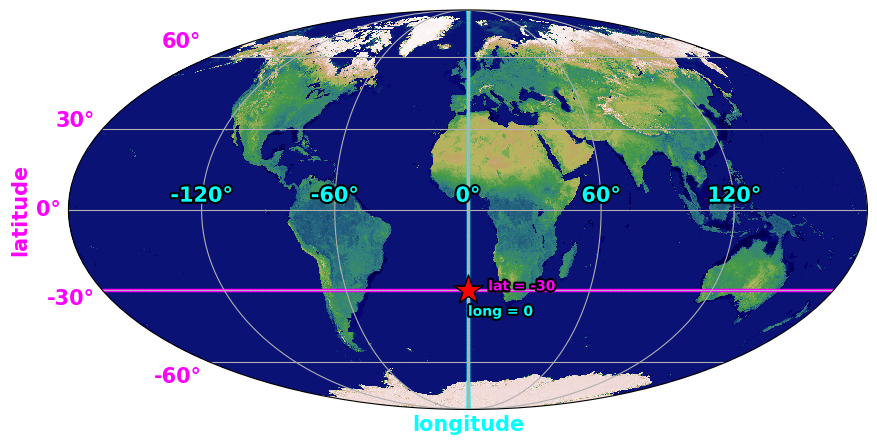

In [293]:
longitude = 0
latitude = -30

plot_earth_map(earth_map, longitude, latitude)


what happens to the location of the star, blue line, and the continents togehter when we change the longitude_offset from 0, 60, 120, 180
what happens to the location of the star, blue line, and the continents togehter when we change the longitude_offset from 0, -60, -120, -180
Do the shapes of the continents stay the same as you change the values? (Chose two locations (like Alaska and the continetal united staes) and watch how far tehy appear from each other on your computer screen as, you change the values)

place longitude_offset bak at zero. Try changing latitude_offset from 0 to 30 to 60 to 90. What happens to teh location of the star, the pink line, and the continents? Do the shapes of the continents stay the same as you change the values?

Remember, the disntaces and shapes of the real continets aren't actually chanign. It's just the projection of the 3D globe onto a 2D map that is changing.

Try chaning the psi_offset to 5, 15 30, 60, 90, 135, 180. Then try -30, -60, -90, -135, -180. What happens to the location of the star, the pink line and blue lines, and the continents? Do the shapes of the continents stay the same as you change the values?

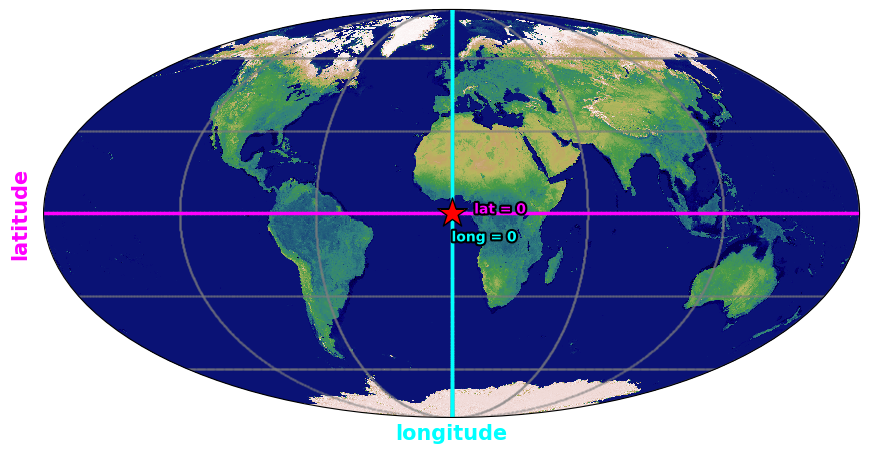

In [348]:
longitude_offset = 0
latitude_offset = 0
psi_offset = 0

plot_transformed_earth_map(earth_map, 0, 0, longitude_offset, latitude_offset, psi_offset)

Here us is a version of the demo where you can change all the values we've introduced together. Try inputting new values for each of them and see what happens

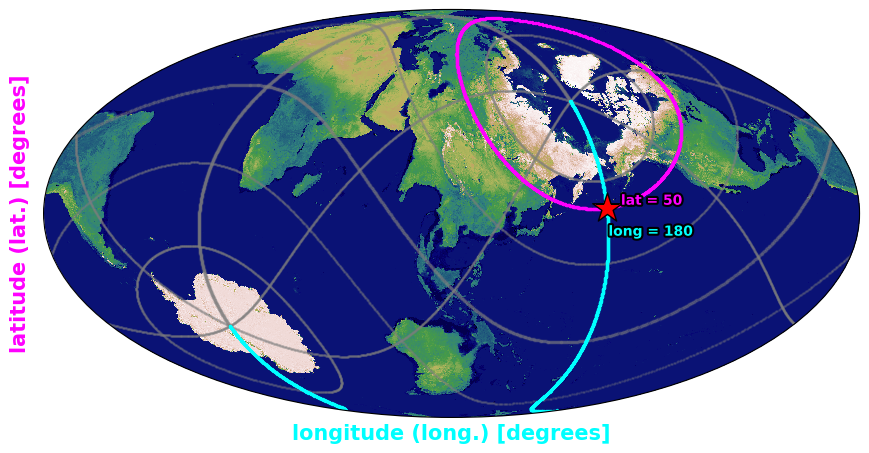

In [434]:
longitude = 180
latitude = 50

longitude_offset = 100
latitude_offset = 20
psi_offset = 45

plot_transformed_earth_map(earth_map, longitude, latitude, longitude_offset, latitude_offset, psi_offset)

Trye out differnt RA values between 0 and 360. What happens when you cross 180 (going from 175 to 185)
Try out different declination values

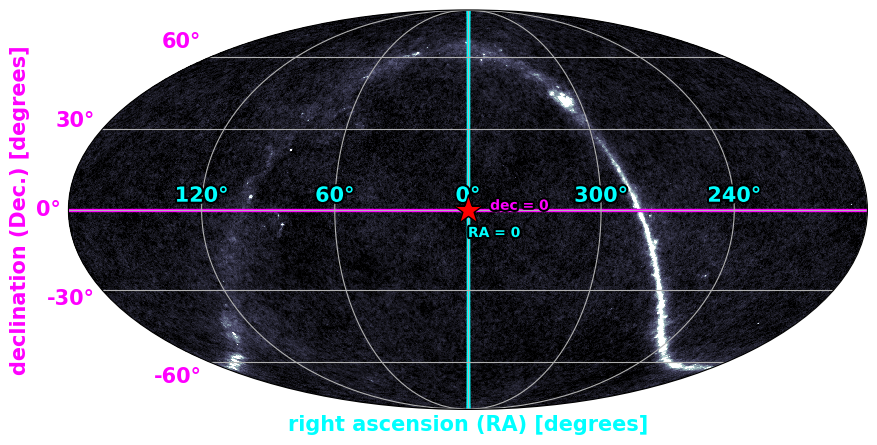

In [536]:
right_ascension = 0
declination = 0
plot_sky_map(sky_map, right_ascension, declination)

match this with the DESI footprint projection by inputting teh corect offset (hin try a positive right_ascension_offset value)

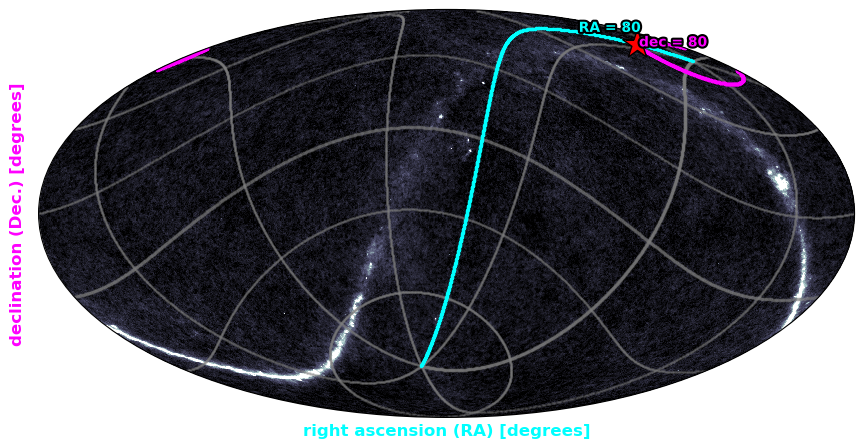

In [541]:
right_ascension = 80
declination = 80

right_ascension_offset = 90
declination_offset = -30
psi_offset = -10


plot_transformed_sky_map(sky_map, right_ascension, declination, right_ascension_offset, declination_offset, psi_offset)

<img src="../../../images/dr1-bright-progress.png" alt="" width="600"/>

<h6> Source : <a href="https://arxiv.org/abs/2503.14745">First Public Data Release of the DESI Survey</a></h6>


Compare your plot with the DESI footprint map we saw before. **Did DESI plan to observe in both the North Galactic Cap footprint and the South Galactic Cap footprint on 2021-09-22?**

<img src="../../../images/dr1-bright-progress.png" alt="" width="600"/>

<h6> Source : <a href="https://arxiv.org/abs/2503.14745">First Public Data Release of the DESI Survey</a></h6>

The green circles in the above map are individual DESI tiles. As the DESI survey carries on, multiple overlapping tiles pile up to cover the entire DESI footprint. You can see this overlapping coverage staring to take effect in the dark green regions.


## Conclusion

In this notebook, we have introduced DESI's map of the universe along with the map projections and coordinate systems that we can use to depict DESI data. We have additionally described how a night of DESI observing works, using overlapping survey tiles to make progress toward the survey's completion. 

The way that galaxies cluster together in DESI's map allows us to test theoretical models of cosmology. In the next notebook, we will introduce various scientific analyses that we can perform with DESI.

![](../../../images/footer.png)

<details>
  <summary><h6>Code solutions, do not open if not allowed</h6></summary>
  
**Exercise 1 : Projecting the Milky Way**
```python
# Try changing the value of map_rotation_angle to various 
# values between 0 and 360 degrees and observe how the 
# apparence of the map changes

map_rotation_angle = 0 # in units of degrees

hp.mollview(
    sky_map,
    rot = (0, 0, map_rotation_angle),
    title="Temperature Map of the Night Sky",
    unit="excess temperature (millikelvin)",
    min=-1,
    max=2,
    cmap = mpl.colormaps['bone']
)
```
An angle of 0 degrees, 90 degrees, 180 degrees, or 270 degrees causes the Milky Way to appear flat.

**Exercise 2 : DESI's Path Through the Night Sky**
```python
# load up right ascension and declination coordinates of tiles for the 2021-09-22 DESI observing plan
ra = np.fromfile('../../../data/20210922_tiles_ra.BIN')
declination = np.fromfile('../../../data/20210922_tiles_dec.BIN')


# show the connected path that DESI takes through the night sky

plt.plot(ra, declination)
# show the locations of the indicidual tiles on the path
plt.scatter(ra, declination)

plt.xlabel('right ascension [degrees]')
plt.ylabel('declination [degrees]')
plt.title('Planned Path of DESI Survey Through The Sky on 2021-09-22')

# add some text to the plot to show where the first and last tiles of the night are located
plt.scatter([266.0, 109.3], [24.8, 40.0], color='red')
plt.text(266.0, 24.8, 'start of the night\n(7:15 pm)')
plt.text(109.3, 40.0, 'end of the night \n(5:19 am)')

# invert the plot's x-axis so that larger right ascension values appear on the left
plt.gca().invert_xaxis()

# Treat the x-axis of the plot as an angle, so that values of 360 degrees wrap
# back around to zero degrees
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(angle_degrees_formatter))

```
The DESI observing plan for 2021-09-22 included tiles in both the North Galactic Cap footprint and the South Galactic Cap footprint. The plan started and ended the night in the South Galactic Cap, while tiles in the middle of the night were in the Northern Galactic Cap.

**Exercise 3 : Creating a Cross Section of DESI Galaxies**
```python
select_cross_section = (z_positions > -5) * (z_positions < 5)

plt.scatter(x_positions[select_cross_section], y_positions[select_cross_section], s=0.5)
plt.axis('equal')
plt.title('10 Mpc/h-wide Cross Section of DESI Galaxies')
plt.xlabel('X Position [Mpc/h]')
plt.ylabel('Y Position [Mpc/h]')
plt.show()
```

  </details>